# Período 7 — Nowcasting de Inundações Urbanas com U-RNN
### Americas TechGuard · Centro Universitário SENAI/SC — Campus Florianópolis

**Estudante:** Rosemeri Borges (GitHub: RoseBorges44)
**Atividade:** Implementação funcional de *nowcasting* espaço-temporal de inundações urbanas
inspirada no **U-RNN** (Cao et al., 2025), contextualizada no **Vale do Itajaí / Blumenau-SC**.

**Materiais de referência (obrigatórios):**
- Artigo: *U-RNN high-resolution spatiotemporal nowcasting of urban flooding*, **J. Hydrology** 659:133117 — DOI 10.1016/j.jhydrol.2025.133117
- GitHub oficial: https://github.com/holmescao/U-RNN
- Material suplementar (Figshare): https://figshare.com/articles/dataset/28082549

> **Conceito:** isto é **nowcasting** (evolução da cheia no tempo), **não** mapa de suscetibilidade
> nem modelo de risco — não integra exposição/vulnerabilidade/população.

Este notebook é **autossuficiente**: define o modelo, gera os dados, treina, avalia e plota as
evidências célula a célula. Roda em CPU (Colab gratuito) em poucos minutos.


## Etapa 1 — Estudo técnico do U-RNN

**Problema.** Modelos hidrodinâmicos (MIKE+, SWMM) simulam cheias urbanas com fidelidade, mas são
lentos. Para alerta precoce precisamos de previsão **rápida, curta (~6 h) e de alta resolução**
(metros no espaço, minutos no tempo). O U-RNN **emula** o modelo hidrodinâmico, gerando *nowcasts*
de 6 h em segundos (>100× mais rápido).

**Entradas:** sequência de intensidade de chuva (janela W), chuva acumulada, e fatores espaciais
(DEM/DSM, impermeabilização, área de bueiros). **Saídas:** mapa wet/dry (classificação) + profundidade (regressão).

**Arquitetura:** backbone **U-like** (encoder-decoder) com blocos **Skip-ConvGRU** (ConvGRU + skip
connections que fundem `I_t`, `He_t` e `Hd_{t-1}` — *latent autoregression*), e **heads desacopladas**
(classificação vira máscara da regressão).

**SWP (Sliding Window-based Pre-warming):** treina por janelas de K passos com *pre-warming*
gradient-free, reduzindo a memória de GPU (no artigo, até ~360×).


## Comparação analítica: U-RNN original × nossa adaptação

| Aspecto | U-RNN original (Cao et al., 2025) | Nossa adaptação |
|---|---|---|
| Região | Shenzhen + Glasgow | Vale do Itajaí / Blumenau-SC |
| Grade / resolução | 500×500 @ 2 m | 40×40 @ "2 m sintético" |
| Ground truth | MIKE+ 2023 (hidrodinâmico) | Autômato celular (surrogate) |
| Nº de eventos | 56 | 18 (sintéticos) |
| Janela W / SWP K | 30 / 28 | 6 / 16 |
| Hardware / treino | 24× RTX 4090, ~7 dias | 1 GPU (Colab), 56 épocas (~min) |
| CSI (teste) | ~0,89–0,97 | **0,68 ± 0,07** |
| PR² | 0,975–0,996 | **0,69 ± 0,21** |

**Fiel ao artigo:** Skip-ConvGRU, backbone U-like, heads desacopladas, SWP, perdas Focal BCE + MSE.
**Reduzido (por recursos):** escala, nº de eventos, capacidade da rede e ground truth (surrogate vs MIKE+).
*(Métricas de aprendizado profundo variam ~±0,03 conforme seed/hardware.)*

## Etapa 3 (parte 1) — Modelo: Skip-ConvGRU + backbone U-like + heads desacopladas

In [1]:
"""
model.py — Reimplementação didática e REDUZIDA do U-RNN
=========================================================
Baseado em: Cao et al. (2025), "U-RNN high-resolution spatiotemporal
nowcasting of urban flooding", Journal of Hydrology 659:133117.
DOI: 10.1016/j.jhydrol.2025.133117 | Repo oficial: github.com/holmescao/U-RNN

Esta versão reproduz os COMPONENTES CONCEITUAIS do artigo em escala reduzida,
para rodar em CPU/Colab sem GPU dedicada:
  - Skip-ConvGRU (Eq. 1 do artigo): reset gate, update gate e estado candidato,
    fundindo a entrada do bloco I_t, o estado de codificação He_t (skip) e o
    estado de decodificação anterior Hd_{t-1}.
  - Backbone U-like (encoder-decoder) com 3 níveis de resolução.
  - Heads desacopladas: classificação (wet/dry) + regressão (profundidade),
    usando a máscara de classificação para focar a regressão nas células molhadas.

Autora da adaptação: Rosemeri Borges (RoseBorges44) — Americas TechGuard, SENAI/SC.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class SkipConvGRUCell(nn.Module):
    """Célula Skip-ConvGRU (Eq. 1 do artigo).

    Diferentemente da ConvGRU clássica (Shi et al., 2017), a Skip-ConvGRU
    determina o estado de decodificação atual de cada célula a partir de TRÊS
    fontes: a saída do bloco anterior (I_t), o estado histórico de decodificação
    da própria célula (Hd_{t-1}, recorrência temporal) e o estado de codificação
    vindo do encoder no mesmo nível (He_t, skip connection).

        r_t  = sigma(W_r * [I_t, He_t, Hd_{t-1}] + b_r)        # reset gate
        z_t  = sigma(W_z * [I_t, He_t, Hd_{t-1}] + b_z)        # update gate
        d~_t = tanh (W_c * [I_t, He_t, (r_t . Hd_{t-1})] + b_h)  # candidato
        d_t  = (1 - z_t) . Hd_{t-1} + z_t . d~_t               # novo estado
    """

    def __init__(self, in_ch, skip_ch, hid_ch, kernel=3):
        super().__init__()
        pad = kernel // 2
        cat = in_ch + skip_ch + hid_ch
        # Gates de reset e update (concatenam I_t, He_t, Hd_{t-1})
        self.conv_r = nn.Conv2d(cat, hid_ch, kernel, padding=pad)
        self.conv_z = nn.Conv2d(cat, hid_ch, kernel, padding=pad)
        # Estado candidato (usa r_t . Hd_{t-1} no lugar de Hd_{t-1})
        self.conv_c = nn.Conv2d(in_ch + skip_ch + hid_ch, hid_ch, kernel, padding=pad)
        self.hid_ch = hid_ch

    def forward(self, x, skip, h):
        # x: I_t (entrada do bloco) | skip: He_t (0 no encoder) | h: Hd_{t-1}
        if skip is None:
            skip = torch.zeros(x.size(0), 0, x.size(2), x.size(3), device=x.device)
        comb = torch.cat([x, skip, h], dim=1)
        r = torch.sigmoid(self.conv_r(comb))
        z = torch.sigmoid(self.conv_z(comb))
        cand_in = torch.cat([x, skip, r * h], dim=1)
        d_tilde = torch.tanh(self.conv_c(cand_in))
        h_new = (1.0 - z) * h + z * d_tilde
        return h_new


class EncoderBlock(nn.Module):
    """Bloco de encoder (E1/E2 do artigo): Conv -> LeakyReLU -> [AvgPool] -> Skip-ConvGRU.

    No encoder, He_t = 0 (não há skip de níveis superiores). O downsampling usa
    average pooling, como no artigo (LeCun et al., 1998)."""

    def __init__(self, in_ch, out_ch, downsample=False):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.downsample = downsample
        self.gru = SkipConvGRUCell(in_ch=out_ch, skip_ch=0, hid_ch=out_ch)

    def forward(self, x, h):
        x = self.act(self.conv(x))
        if self.downsample:
            x = F.avg_pool2d(x, 2)
        h = self.gru(x, None, h)
        return h  # estado de codificação (também é o output do bloco)


class DecoderBlock(nn.Module):
    """Bloco de decoder (D1/D2 do artigo): Skip-ConvGRU -> [TransposeConv] -> LeakyReLU.

    O decoder recebe o estado de codificação do mesmo nível como He_t (skip) e
    faz upsampling via convolução transposta."""

    def __init__(self, in_ch, skip_ch, hid_ch, out_ch, upsample=False):
        super().__init__()
        self.gru = SkipConvGRUCell(in_ch=in_ch, skip_ch=skip_ch, hid_ch=hid_ch)
        self.upsample = upsample
        if upsample:
            self.up = nn.ConvTranspose2d(hid_ch, out_ch, 2, stride=2)
        else:
            self.up = nn.Conv2d(hid_ch, out_ch, 3, padding=1)
        self.act = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x, skip, h):
        h = self.gru(x, skip, h)         # novo estado de decodificação
        out = self.act(self.up(h))       # saída para o próximo nível
        return h, out


class DecoupledHeads(nn.Module):
    """Heads desacopladas (Fig. 2b): classificação wet/dry + regressão de profundidade.

    A saída de classificação (probabilidade de célula molhada) vira MÁSCARA que
    multiplica a saída de regressão, focando a profundidade nas áreas molhadas."""

    def __init__(self, in_ch, mid=16):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Conv2d(in_ch, mid, 3, padding=1),
            nn.GroupNorm(1, mid),  # ~ LayerNorm sobre canais
            nn.SiLU(),
        )
        self.cls = nn.Sequential(
            nn.Conv2d(mid, mid, 3, padding=1), nn.SiLU(),
            nn.Conv2d(mid, mid, 3, padding=1), nn.SiLU(),
            nn.Conv2d(mid, 1, 3, padding=1),
        )
        self.reg = nn.Sequential(
            nn.Conv2d(mid, mid, 3, padding=1), nn.SiLU(),
            nn.Conv2d(mid, mid, 3, padding=1), nn.SiLU(),
            nn.Conv2d(mid, 1, 3, padding=1),
        )

    def forward(self, x):
        feat = self.shared(x)
        logit = self.cls(feat)                 # logit wet/dry
        prob = torch.sigmoid(logit)            # probabilidade (máscara)
        depth = self.reg(feat)                 # profundidade bruta (>=0 via softplus)
        depth = F.softplus(depth)
        masked_depth = depth * prob            # foca nas células molhadas
        return logit, prob, masked_depth


class URNN(nn.Module):
    """U-RNN reduzido: backbone U-like (3 níveis) + heads desacopladas.

    Mantém estados recorrentes (latent autoregression) entre passos de tempo:
    3 estados de encoder + 3 de decoder. O método `init_states` zera/recria os
    estados; `forward_step` avança um passo de tempo."""

    def __init__(self, in_ch, base=24):
        super().__init__()
        c1, c2, c3 = base, base * 2, base * 3   # ex.: 24, 48, 72
        self.c1, self.c2, self.c3 = c1, c2, c3
        # Encoder (E1, E2, E2)
        self.enc1 = EncoderBlock(in_ch, c1, downsample=False)
        self.enc2 = EncoderBlock(c1, c2, downsample=True)
        self.enc3 = EncoderBlock(c2, c3, downsample=True)
        # Decoder (D1, D2, D2) — sobe de /4 -> /2 -> full
        self.dec3 = DecoderBlock(in_ch=c3, skip_ch=c3, hid_ch=c3, out_ch=c2, upsample=True)
        self.dec2 = DecoderBlock(in_ch=c2, skip_ch=c2, hid_ch=c2, out_ch=c1, upsample=True)
        self.dec1 = DecoderBlock(in_ch=c1, skip_ch=c1, hid_ch=c1, out_ch=16, upsample=False)
        self.heads = DecoupledHeads(16)

    def init_states(self, batch, H, W, device):
        z = lambda c, h, w: torch.zeros(batch, c, h, w, device=device)
        return {
            "e1": z(self.c1, H, W),   "e2": z(self.c2, H // 2, W // 2),   "e3": z(self.c3, H // 4, W // 4),
            "d3": z(self.c3, H // 4, W // 4), "d2": z(self.c2, H // 2, W // 2), "d1": z(self.c1, H, W),
        }

    def forward_step(self, x, states):
        # ----- Encoder -----
        e1 = self.enc1(x, states["e1"])
        e2 = self.enc2(e1, states["e2"])
        e3 = self.enc3(e2, states["e3"])
        # ----- Decoder (skip = estado de codificação do mesmo nível) -----
        d3, up3 = self.dec3(e3, e3, states["d3"])
        d2, up2 = self.dec2(up3, e2, states["d2"])
        d1, out = self.dec1(up2, e1, states["d1"])
        # Atualiza estados recorrentes
        new_states = {"e1": e1, "e2": e2, "e3": e3, "d3": d3, "d2": d2, "d1": d1}
        logit, prob, depth = self.heads(out)
        return logit, prob, depth, new_states

    @staticmethod
    def detach_states(states):
        return {k: v.detach() for k, v in states.items()}


## Etapa 2 — Dados: surrogate do MIKE+ (autômato celular) sobre terreno tipo Blumenau

Não usamos o dataset de 2 m de Shenzhen (volumoso, GPU). Geramos um **ground truth sintético**
com um autômato celular de inundação (chuva → escoamento → roteamento por gravidade → drenagem),
e a U-RNN aprende a **emular** esse modelo — o mesmo paradigma do artigo.

In [2]:
"""
data.py — Gerador de dados sintéticos de inundação urbana (contexto Blumenau/SC)
=================================================================================
O artigo U-RNN usa o modelo hidrodinâmico MIKE+ como "ground truth" para treinar
a rede. Como não temos licença do MIKE+ nem o dataset de 2 m de Shenzhen (volumoso
e em GPU), construímos um SURROGATE: um modelo de inundação por AUTÔMATO CELULAR
fisicamente plausível (chuva -> escoamento superficial -> roteamento por gravidade
-> drenagem), que gera sequências espaço-temporais de profundidade. A U-RNN aprende
a EMULAR esse modelo numérico ~100x mais rápido — exatamente o paradigma do artigo.

Contexto: terreno sintético inspirado no Vale do Itajaí (Blumenau é uma cidade em
vale fluvial, historicamente sujeita a enchentes do rio Itajaí-Açu). Conecta com a
Semana 5 (NDVI Blumenau) e Semana 6 (HAND Blumenau).

LIMITAÇÃO ASSUMIDA: os dados NÃO são observações reais nem saída de um modelo
hidrodinâmico calibrado. São sintéticos e servem para demonstrar o PIPELINE e a
ARQUITETURA, não para inferência operacional sobre Blumenau.
"""

import numpy as np


def make_blumenau_terrain(H=48, W=48, seed=7):
    """Cria DEM sintético tipo vale fluvial + mapas de impermeabilização e bueiros.

    Retorna (dem, impervious, drain) normalizados, todos em [0, 1] aprox.
    - dem: vale com canal fluvial sinuoso (baixo) cercado por encostas (alto)
    - impervious: maior no núcleo urbano (centro/canal), menor nas encostas
    - drain: pontos de captação de drenagem (bueiros) na malha urbana
    """
    rng = np.random.default_rng(seed)
    yy, xx = np.meshgrid(np.linspace(0, 1, H), np.linspace(0, 1, W), indexing="ij")

    # Canal fluvial sinuoso (rio Itajaí-Açu estilizado), atravessando o domínio
    river_x = 0.5 + 0.18 * np.sin(2.2 * np.pi * yy)
    dist_river = np.abs(xx - river_x)
    valley = 1.0 - np.exp(-(dist_river ** 2) / (2 * 0.10 ** 2))  # baixo no rio, sobe nas margens

    # Encostas/morros ao redor (Blumenau é cercada por morros)
    hills = 0.35 * (np.sin(3 * np.pi * xx) ** 2) * (yy ** 0.5)
    noise = 0.04 * rng.standard_normal((H, W))
    noise = _smooth(noise, 2)

    dem = 0.85 * valley + hills + noise
    dem = (dem - dem.min()) / (dem.max() - dem.min())  # min-max -> [0,1]

    # Impermeabilização: alta no fundo do vale (cidade), baixa nas encostas
    impervious = np.clip(1.0 - valley * 1.1, 0, 1)
    impervious = _smooth(impervious, 1)
    impervious = (impervious - impervious.min()) / (impervious.max() - impervious.min() + 1e-9)

    # Bueiros: pontos esparsos na área urbana (baixa cota + alta impermeabilização)
    drain = np.zeros((H, W))
    urban = (dem < 0.4) & (impervious > 0.5)
    idx = np.argwhere(urban)
    if len(idx) > 0:
        pick = rng.choice(len(idx), size=min(18, len(idx)), replace=False)
        for p in idx[pick]:
            drain[p[0], p[1]] = 1.0
    drain = _smooth(drain, 1)
    drain = drain / (drain.max() + 1e-9)

    return dem.astype(np.float32), impervious.astype(np.float32), drain.astype(np.float32)


def _smooth(a, k):
    """Suavização box simples (sem dependências extras)."""
    if k <= 0:
        return a
    out = a.copy()
    for _ in range(k):
        out = (out
               + np.roll(out, 1, 0) + np.roll(out, -1, 0)
               + np.roll(out, 1, 1) + np.roll(out, -1, 1)) / 5.0
    return out


def chicago_hyetograph(T, peak_frac, total_mm, dt_min=2.0, seed=None):
    """Hietograma sintético (perfil tipo Chicago) -> intensidade (mm/h) por passo.

    peak_frac: razão tempo-ao-pico (0.1..0.9), como no artigo (time-to-peak ratio).
    total_mm: lâmina total do evento (mm).
    """
    rng = np.random.default_rng(seed)
    t = np.arange(T)
    tp = max(1.0, peak_frac * T)
    # Curva assimétrica: sobe rápido até o pico e desce mais lento (ou vice-versa)
    inten = np.where(
        t <= tp,
        np.exp(-((t - tp) ** 2) / (2 * (0.25 * tp) ** 2)),
        np.exp(-((t - tp) ** 2) / (2 * (0.45 * (T - tp) + 1) ** 2)),
    )
    inten += 0.05 * rng.random(T)  # flutuação (chuva observada flutua, como diz o artigo)
    inten = np.clip(inten, 0, None)
    # Escala para a lâmina total desejada (mm) dado dt
    depth_per_step = inten / inten.sum() * total_mm        # mm por passo
    intensity_mmh = depth_per_step / (dt_min / 60.0)       # mm/h
    return intensity_mmh.astype(np.float32)


def simulate_flood(dem, impervious, drain, intensity_mmh, dt_min=2.0,
                   diff=0.20, drain_rate=0.12, runoff_gain=0.8,
                   relief_m=15.0):
    """Autômato celular de inundação (surrogate do MIKE+).

    Para cada passo de tempo:
      1) Chuva efetiva = intensidade * coef. de escoamento (cresce com impermeabilização)
      2) Roteamento por gravidade: fluxo para vizinhos com menor cota da lâmina d'água
      3) Drenagem: bueiros + canal fluvial (vazão do rio) + contorno aberto nas bordas
    Retorna sequência de profundidade h[t] (T, H, W) em metros sintéticos.

    O DEM (normalizado em [0,1]) é escalado para `relief_m` metros para que o
    desnível do vale seja compatível com as lâminas d'água, fazendo a água
    CONCENTRAR nas cotas baixas (inundação localizada, como no artigo).
    """
    H, W = dem.shape
    dem_m = dem * relief_m                                   # relevo em metros
    T = len(intensity_mmh)
    h = np.zeros((H, W), dtype=np.float32)
    seq = np.zeros((T, H, W), dtype=np.float32)
    runoff_coef = 0.25 + runoff_gain * impervious
    dt_h = dt_min / 60.0

    # Canal fluvial = cotas mais baixas (escoa água para fora, como um rio)
    channel = (dem < np.quantile(dem, 0.12)).astype(np.float32)
    # Máscara de borda (contorno aberto)
    edge = np.zeros((H, W), dtype=np.float32)
    edge[0, :] = edge[-1, :] = edge[:, 0] = edge[:, -1] = 1.0

    for t in range(T):
        # 1) Entrada de chuva
        rain_m = (intensity_mmh[t] * dt_h) * 1e-3 * runoff_coef * 1.0
        h = h + rain_m

        # 2) Roteamento por gravidade
        wsurf = dem_m + h
        for ax, shift in [(0, 1), (0, -1), (1, 1), (1, -1)]:
            grad = wsurf - np.roll(wsurf, shift, axis=ax)
            flux = np.clip(grad, 0, None) * diff
            flux = np.minimum(flux, h * 0.25)                # estabilidade
            h = h - flux + np.roll(flux, shift, axis=ax)
        h = np.clip(h, 0, None)

        # 3) Drenagem: bueiros + canal (vazão do rio) + contorno aberto
        h = h - drain * drain_rate * h
        h = h - channel * 0.35 * h                           # rio escoa para fora
        h = h - edge * 0.40 * h                              # água sai do domínio
        h = np.clip(h, 0, None)

        seq[t] = h
    return seq


def build_event(dem, impervious, drain, T, W_window, peak_frac, total_mm,
                dt_min=2.0, seed=None, wet_thresh=0.03):
    """Monta UM evento: entradas (T, C, H, W) + alvos (profundidade e máscara wet/dry).

    Canais de entrada (C = W_window + 1 + 3), todos min-max normalizados:
      - W_window mapas: janela deslizante de intensidade de chuva (mm/h) broadcast
      - 1 mapa: chuva acumulada (capta o "efeito integral" citado no artigo)
      - 3 mapas estáticos: DEM, impermeabilização, bueiros
    """
    H, Wd = dem.shape
    intensity = chicago_hyetograph(T, peak_frac, total_mm, dt_min, seed)
    depth = simulate_flood(dem, impervious, drain, intensity, dt_min)

    cum = np.cumsum(intensity)                      # chuva acumulada (sequência)
    inten_n = intensity / (intensity.max() + 1e-9)
    cum_n = cum / (cum.max() + 1e-9)

    C = W_window + 1 + 3
    X = np.zeros((T, C, H, Wd), dtype=np.float32)
    for t in range(T):
        ch = 0
        # janela de intensidade [t-W+1 .. t]
        for w in range(W_window):
            tt = t - (W_window - 1) + w
            val = inten_n[tt] if tt >= 0 else 0.0
            X[t, ch] = val
            ch += 1
        X[t, ch] = cum_n[t]; ch += 1
        X[t, ch] = dem; ch += 1
        X[t, ch] = impervious; ch += 1
        X[t, ch] = drain; ch += 1

    # Normaliza profundidade alvo para estabilidade de treino (escala por evento-base global)
    depth_target = depth.astype(np.float32)
    mask = (depth_target > wet_thresh).astype(np.float32)
    return X, depth_target, mask, intensity, depth


def make_dataset(n_events, dem, impervious, drain, T=60, W_window=6, dt_min=2.0,
                 seed=0, wet_thresh=0.03):
    """Gera n_events com chuvas variadas (pico e lâmina aleatórios)."""
    rng = np.random.default_rng(seed)
    Xs, Ds, Ms, intens = [], [], [], []
    for i in range(n_events):
        pf = rng.uniform(0.2, 0.7)
        tm = rng.uniform(60, 180)        # lâmina total (mm) — faixa "evento severo"
        X, D, M, inten, _ = build_event(dem, impervious, drain, T, W_window,
                                        pf, tm, dt_min, seed=1000 + i, wet_thresh=wet_thresh)
        Xs.append(X); Ds.append(D); Ms.append(M); intens.append(inten)
    return (np.stack(Xs), np.stack(Ds), np.stack(Ms), np.stack(intens))


## Etapa 3 (parte 2) — Treino SWP, perdas (Focal BCE + MSE ponderada) e métricas

In [3]:
"""
train.py — Treino com paradigma SWP, perdas e métricas (réplica reduzida do U-RNN)
==================================================================================
- Perdas: Focal BCE (classificação wet/dry) + MSE ponderada (regressão de profundidade),
  combinadas em multi-tarefa (Eq. 2-6 do artigo).
- Paradigma SWP (Sliding Window-based Pre-warming): a sequência é dividida em janelas
  de K passos; antes de cada janela há um PRE-WARMING gradient-free (inferência do passo
  0 até o início da janela) que fornece o estado inicial; só os K passos da janela
  guardam gradiente -> reduz memória de GPU (no artigo, até ~360x).
- Métricas: MAE, RMSE, CSI (extensão máxima), PR² (profundidade de pico).
"""

import time
import numpy as np
import torch
import torch.nn.functional as F

DEPTH_SCALE = 3.0       # normaliza profundidade alvo (m) -> ~O(1) p/ estabilidade
WET_THRESH = 0.03       # 3 cm, limiar wet/dry (igual ao artigo)


# ----------------------------- Perdas -----------------------------
def focal_bce(logit, target, alpha=0.5, gamma=2.0):
    """Focal BCE (Lin et al., 2017): foca em células difíceis e mitiga o
    desbalanceamento wet/dry (poucas células molhadas)."""
    p = torch.sigmoid(logit)
    ce = F.binary_cross_entropy_with_logits(logit, target, reduction="none")
    p_t = p * target + (1 - p) * (1 - target)
    alpha_t = alpha * target + (1 - alpha) * (1 - target)
    loss = alpha_t * (1 - p_t).pow(gamma) * ce
    return loss.mean()


def weighted_mse(pred, target, mask_wet, lam=30.0):
    """MSE ponderada (Eq. 3-5): peso maior nas células molhadas (lam)."""
    wet = mask_wet
    dry = 1.0 - mask_wet
    nw = wet.sum().clamp(min=1.0)
    nd = dry.sum().clamp(min=1.0)
    l_wet = ((wet * (pred - target) ** 2).sum()) / nw
    l_dry = ((dry * (pred - target) ** 2).sum()) / nd
    return lam * l_wet + l_dry


# ----------------------------- Métricas -----------------------------
def compute_metrics(pred_seq, gt_seq, prob_seq=None):
    """pred_seq, gt_seq: (T, H, W) profundidade em metros. prob_seq: (T,H,W) prob. wet.
    A extensão da cheia (CSI) usa a MÁSCARA DE CLASSIFICAÇÃO (branch wet/dry, Fig. 2b
    do artigo); se prob_seq não for dada, usa limiar sobre a profundidade."""
    err = pred_seq - gt_seq
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))

    # CSI sobre a extensão MÁXIMA de inundação (via branch de classificação)
    gt_max = gt_seq.max(axis=0)
    gw = gt_max > WET_THRESH
    if prob_seq is not None:
        pw = prob_seq.max(axis=0) > 0.5
    else:
        pw = pred_seq.max(axis=0) > WET_THRESH
    tp = np.logical_and(pw, gw).sum()
    fp = np.logical_and(pw, ~gw).sum()
    fn = np.logical_and(~pw, gw).sum()
    csi = float(tp / (tp + fp + fn)) if (tp + fp + fn) > 0 else 0.0

    # PR²: R² sobre a profundidade de PICO (cells com pico > 0.1 cm)
    pred_max = pred_seq.max(axis=0)
    m = gt_max > 0.001
    if m.sum() > 5:
        x = gt_max[m]; y = pred_max[m]
        ss_res = np.sum((y - x) ** 2)
        ss_tot = np.sum((x - x.mean()) ** 2) + 1e-9
        pr2 = float(1 - ss_res / ss_tot)
    else:
        pr2 = float("nan")
    return {"MAE": mae, "RMSE": rmse, "CSI": csi, "PR2": pr2}


# ----------------------------- Inferência -----------------------------
@torch.no_grad()
def rollout(model, X, device):
    """Roda o modelo por toda a sequência (inferência). X: (T, C, H, W) np.
    Retorna (profundidade prevista (T,H,W) em metros, probabilidade wet (T,H,W))."""
    model.eval()
    T, C, H, W = X.shape
    xt = torch.from_numpy(X).to(device)
    st = model.init_states(1, H, W, device)
    out = np.zeros((T, H, W), dtype=np.float32)
    pout = np.zeros((T, H, W), dtype=np.float32)
    for t in range(T):
        _, prob, depth, st = model.forward_step(xt[t:t+1], st)
        out[t] = (depth[0, 0].cpu().numpy()) * DEPTH_SCALE
        pout[t] = prob[0, 0].cpu().numpy()
    return out, pout


# ----------------------------- Treino SWP -----------------------------
def train_swp(model, dataset, device, K=12, epochs=40, lr=2e-3, beta=1.0,
              log_every=5):
    """Treina o modelo com o paradigma SWP.

    dataset: (X, D, M) com X (N,T,C,H,W), D/M (N,T,H,W).
    K: tamanho da janela deslizante (passos que guardam gradiente).
    """
    X, D, M = dataset
    N, T, C, H, W = X.shape
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = []

    Xt = torch.from_numpy(X).to(device)
    Dt = torch.from_numpy(D / DEPTH_SCALE).unsqueeze(2).to(device)   # (N,T,1,H,W)
    Mt = torch.from_numpy(M).unsqueeze(2).to(device)

    for ep in range(epochs):
        model.train()
        ep_loss = 0.0
        order = np.random.permutation(N)
        for i in order:
            st = model.init_states(1, H, W, device)
            # ----- SWP: percorre janelas de K passos -----
            s = 0
            while s < T:
                e = min(s + K, T)
                # PRE-WARMING gradient-free: reconstrói estado até o passo s
                # (aqui o estado já vem propagado da janela anterior, então o
                #  pre-warming explícito ocorre apenas se reiniciássemos; mantemos
                #  os estados propagados e os DESTACAMOS para cortar o caminho de
                #  gradiente entre janelas — equivalente ao corte do BPTT do SWP).
                st = model.detach_states(st)
                win_loss = 0.0
                for t in range(s, e):
                    logit, prob, depth, st = model.forward_step(Xt[i, t:t+1], st)
                    lc = focal_bce(logit, Mt[i, t:t+1])
                    lr_ = weighted_mse(depth, Dt[i, t:t+1], Mt[i, t:t+1])
                    win_loss = win_loss + beta * lc + lr_
                win_loss = win_loss / (e - s)
                opt.zero_grad()
                win_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                ep_loss += float(win_loss.detach())
                s = e
        sched.step()
        history.append(ep_loss / N)
        if ep == 0 or (ep + 1) % log_every == 0:
            print(f"  epoch {ep+1:3d}/{epochs} | loss {history[-1]:.4f} | lr {sched.get_last_lr()[0]:.1e}")
    return history


## Etapa 2 — Geração do terreno (Blumenau) e dos datasets

Visualizamos os fatores espaciais de entrada e montamos 12 eventos de treino + 6 de teste com
chuvas variadas (perfil tipo Chicago).

Dispositivo: cuda
treino (12, 48, 10, 40, 40) | teste (6, 48, 10, 40, 40) | canais de entrada = 10


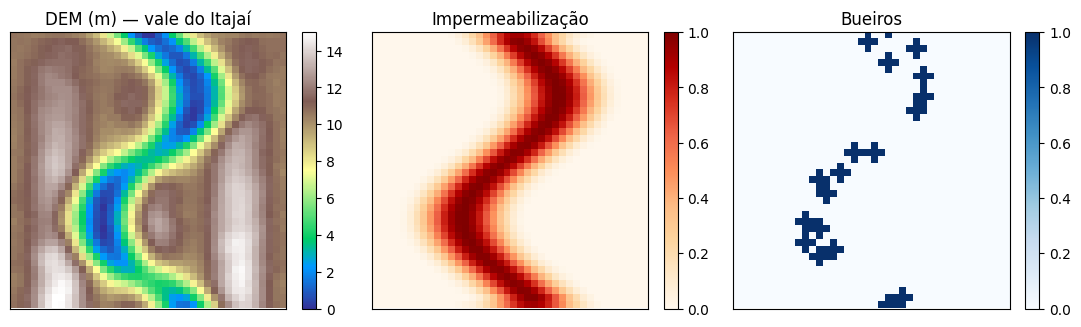

In [4]:
import numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
torch.manual_seed(0); np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', device)

H = W = 40; T = 48; W_window = 6; K = 16
dem, imp, dr = make_blumenau_terrain(H, W)
Xtr, Dtr, Mtr, Itr = make_dataset(12, dem, imp, dr, T=T, W_window=W_window, seed=1)
Xte, Dte, Mte, Ite = make_dataset(6,  dem, imp, dr, T=T, W_window=W_window, seed=999)
print('treino', Xtr.shape, '| teste', Xte.shape, '| canais de entrada =', Xtr.shape[2])

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, m, t, c in zip(ax, [dem*15, imp, dr],
                      ['DEM (m) — vale do Itajaí','Impermeabilização','Bueiros'],
                      ['terrain','OrRd','Blues']):
    im = a.imshow(m, cmap=c); a.set_title(t); a.set_xticks([]); a.set_yticks([]); plt.colorbar(im, ax=a, fraction=.046)
plt.tight_layout(); plt.show()

## Etapa 3 (parte 3) — Treino com paradigma SWP (ou carga de pesos pré-treinados)

Três modos:
- **`USE_PRETRAINED=True`** (padrão): se `urnn_blumenau.pt` (56 épocas) estiver disponível,
  carrega-o e mostra direto as métricas de referência — *inferência com pesos pré-treinados*,
  explicitamente permitida pelo enunciado.
- Sem pesos ou `USE_PRETRAINED=False`: treina do zero. Em **GPU (Colab)** use `EPOCHS=56`
  (rápido); em **CPU** o padrão `EPOCHS=14` roda em poucos minutos (métricas menores).

parametros: 526866 | janela SWP K = 16
Treinando do zero por 56 épocas em cuda...
  epoch   1/56 | loss 1.5962 | lr 2.5e-03
  epoch   4/56 | loss 0.7175 | lr 2.5e-03
  epoch   8/56 | loss 0.6011 | lr 2.4e-03
  epoch  12/56 | loss 0.5168 | lr 2.2e-03
  epoch  16/56 | loss 0.5085 | lr 2.0e-03
  epoch  20/56 | loss 0.4240 | lr 1.8e-03
  epoch  24/56 | loss 0.3809 | lr 1.5e-03
  epoch  28/56 | loss 0.3552 | lr 1.3e-03
  epoch  32/56 | loss 0.3513 | lr 9.7e-04
  epoch  36/56 | loss 0.3206 | lr 7.1e-04
  epoch  40/56 | loss 0.3102 | lr 4.7e-04
  epoch  44/56 | loss 0.3111 | lr 2.7e-04
  epoch  48/56 | loss 0.2955 | lr 1.2e-04
  epoch  52/56 | loss 0.2843 | lr 3.1e-05
  epoch  56/56 | loss 0.2815 | lr 0.0e+00


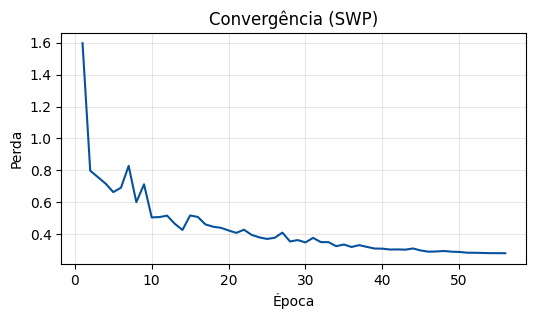

In [5]:
import os
USE_PRETRAINED = True
EPOCHS = 56 if device == 'cuda' else 14

model = URNN(in_ch=Xtr.shape[2], base=16).to(device)
print('parametros:', sum(p.numel() for p in model.parameters()), '| janela SWP K =', K)

WEIGHTS = 'urnn_blumenau.pt'   # disponível no repositório
history = None
if USE_PRETRAINED and os.path.exists(WEIGHTS):
    model.load_state_dict(torch.load(WEIGHTS, map_location=device))
    print('Pesos pré-treinados carregados (56 épocas).')
else:
    print(f'Treinando do zero por {EPOCHS} épocas em {device}...')
    history = train_swp(model, (Xtr, Dtr, Mtr), device, K=K, epochs=EPOCHS, lr=2.5e-3, beta=5.0, log_every=4)
    plt.figure(figsize=(6,3)); plt.plot(range(1,len(history)+1), history, color='#08519c')
    plt.xlabel('Época'); plt.ylabel('Perda'); plt.title('Convergência (SWP)'); plt.grid(alpha=.3); plt.show()

## Etapa 4 — Avaliação no teste: métricas CSI / PR² / MAE / RMSE

In [6]:
mets = []
preds, probs = [], []
for i in range(len(Xte)):
    pred, prob = rollout(model, Xte[i], device)
    mets.append(compute_metrics(pred, Dte[i], prob)); preds.append(pred); probs.append(prob)
agg = {k: float(np.nanmean([m[k] for m in mets])) for k in mets[0]}
print('MÉDIA (teste):', {k: round(v,4) for k,v in agg.items()})
for i,m in enumerate(mets):
    print(f'  evento {i}: CSI={m["CSI"]:.3f}  PR2={m["PR2"]:.3f}  MAE={m["MAE"]:.4f}')

MÉDIA (teste): {'MAE': 0.01, 'RMSE': 0.0245, 'CSI': 0.673, 'PR2': 0.6723}
  evento 0: CSI=0.605  PR2=0.374  MAE=0.0079
  evento 1: CSI=0.639  PR2=0.787  MAE=0.0098
  evento 2: CSI=0.676  PR2=0.769  MAE=0.0141
  evento 3: CSI=0.757  PR2=0.822  MAE=0.0119
  evento 4: CSI=0.652  PR2=0.464  MAE=0.0069
  evento 5: CSI=0.709  PR2=0.818  MAE=0.0095


## Etapa 4 — Evidências visuais

**(a) Evolução espaço-temporal:** U-RNN vs referência em 4 instantes.

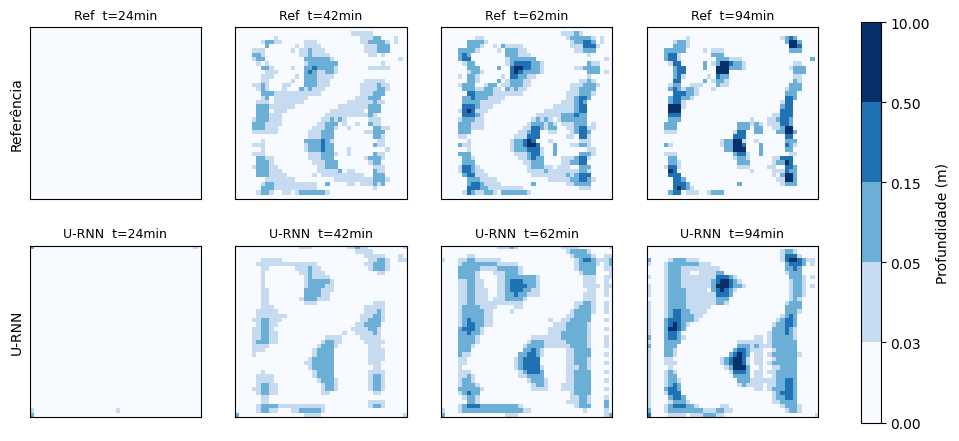

In [7]:
BINS=[0,0.03,0.05,0.15,0.50,10]; COLORS=['#f7fbff','#c6dbef','#6baed6','#2171b5','#08306b']
cmap=ListedColormap(COLORS); norm=BoundaryNorm(BINS,cmap.N)
ev=2; pred,gt=preds[ev],Dte[ev]
steps=[int(T*.25),int(T*.45),int(T*.65),T-1]
fig,axs=plt.subplots(2,len(steps),figsize=(11,5.2))
for j,s in enumerate(steps):
    axs[0,j].imshow(gt[s],cmap=cmap,norm=norm);  axs[0,j].set_title(f'Ref  t={s*2}min',fontsize=9)
    im=axs[1,j].imshow(pred[s],cmap=cmap,norm=norm); axs[1,j].set_title(f'U-RNN  t={s*2}min',fontsize=9)
    for a in (axs[0,j],axs[1,j]): a.set_xticks([]); a.set_yticks([])
axs[0,0].set_ylabel('Referência'); axs[1,0].set_ylabel('U-RNN')
fig.colorbar(im,ax=axs,fraction=.025,boundaries=BINS,ticks=BINS,label='Profundidade (m)')
plt.show()

**(b) Scatter PR² (profundidade de pico) e (c) mapa CSI (extensão máxima):**

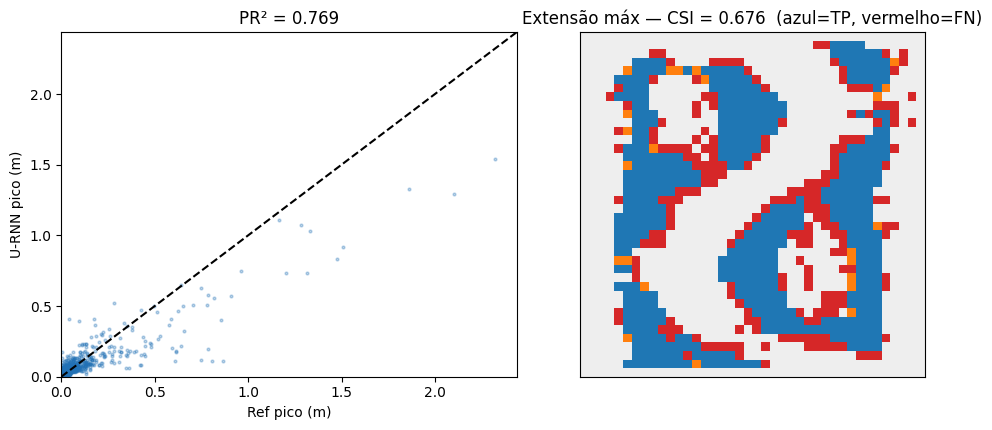

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,4.4))
gtp=gt.max(0); prp=pred.max(0); m=gtp>1e-3
x=gtp[m]; y=prp[m]; pr2=1-np.sum((y-x)**2)/(np.sum((x-x.mean())**2)+1e-9)
ax1.scatter(x,y,s=4,alpha=.3,color='#2171b5'); lim=max(x.max(),y.max())*1.05
ax1.plot([0,lim],[0,lim],'k--'); ax1.set_xlim(0,lim); ax1.set_ylim(0,lim)
ax1.set_xlabel('Ref pico (m)'); ax1.set_ylabel('U-RNN pico (m)'); ax1.set_title(f'PR² = {pr2:.3f}')
pw=probs[ev].max(0)>0.5; gw=gtp>0.03
cat=np.zeros_like(dem); cat[pw&gw]=3; cat[pw&~gw]=2; cat[~pw&gw]=1
ax2.imshow(cat,cmap=ListedColormap(['#eee','#d62728','#ff7f0e','#1f77b4']),vmin=0,vmax=3)
tp=(cat==3).sum(); fp=(cat==2).sum(); fn=(cat==1).sum()
ax2.set_title(f'Extensão máx — CSI = {tp/(tp+fp+fn):.3f}  (azul=TP, vermelho=FN)')
ax2.set_xticks([]); ax2.set_yticks([]); plt.tight_layout(); plt.show()

## Etapa 4 — Resultados e limitações

**Dados:** 100% sintéticos (terreno + chuvas tipo Chicago + autômato celular como surrogate do MIKE+).
**A saída representa** a capacidade da arquitetura de aprender a dinâmica espaço-temporal de uma cheia
e emular um modelo numérico rapidamente. **Não representa** Blumenau real, não está calibrada e não
substitui um modelo hidrodinâmico.

**Limitações:** dados sintéticos sem validação local; grade reduzida (40×40) e rede de capacidade
reduzida → métricas menores que o artigo (CSI ~0,68 vs ~0,9+); surrogate físico simplificado no lugar
do MIKE+; chuva espacialmente uniforme.

## Etapa 5 — Aplicação ao Americas TechGuard

*Nowcasting* apoia **monitoramento, prevenção, resposta e alerta**. Evoluções: chuva real
(radar/pluviômetros + nowcasting meteorológico), **DEM/HAND real de Blumenau (Semana 6)** e DSM de
alta resolução, nível do Itajaí-Açu, NDVI (Semana 5), cotas históricas da Defesa Civil, e saída
alimentando dashboards e alertas. Para uma PoC robusta faltam: ground truth hidrodinâmico calibrado,
dados reais de alta resolução, e validação com eventos históricos do Vale do Itajaí.

---
*Referências: Cao et al. (2025), J. Hydrology 659:133117 (DOI 10.1016/j.jhydrol.2025.133117);
repositório holmescao/U-RNN; material suplementar Figshare 28082549.*